# Sparse Estimation

Sparse estimation is a statistical and machine learning approach for estimating model parameters when we believe that only a relatively small number of features are truly important.

The central idea is to obtain parameter estimates where many coefficients are exactly zero.

For a linear model,

$$
y = X\beta + \epsilon
$$

where:

- $X$ is the feature matrix
- $y$ is the target variable
- $\beta$ is the vector of model coefficients
- $\epsilon$ is noise

ordinary least squares estimates $\beta$ by minimizing the residual sum of squares:

$$
\hat{\beta}_{OLS}
=
\arg\min_{\beta}
\frac{1}{2n}
\|y-X\beta\|_2^2
$$

However, OLS generally produces dense coefficient vectors, meaning most coefficients are non-zero.

Sparse estimation modifies the optimization problem by adding a regularization term that encourages some coefficients to become exactly zero.

The most important sparse estimation method is Lasso regression.

## Why Sparse Estimation?

Modern datasets can contain a very large number of features.

For example:

- gene expression datasets
- text classification
- image representations
- financial datasets
- sensor data
- high-dimensional scientific data

Often, only a subset of these features contributes significantly to prediction.

Suppose a model contains 1000 features, but only 20 are actually useful.

A dense model may estimate:

$$
\beta =
(\beta_1,\beta_2,\ldots,\beta_{1000})
$$

with almost every coefficient non-zero.

A sparse model attempts to obtain something like:

$$
\beta =
(\beta_1,0,0,\beta_4,0,\ldots,\beta_{20},0,\ldots)
$$

Therefore, sparse estimation provides:

1. Feature selection
2. Simpler models
3. Improved interpretability
4. Reduced computational requirements
5. Protection against overfitting in high-dimensional settings

## Ordinary Least Squares

Before understanding sparse estimation, we need to understand the standard estimation problem.

For linear regression:

$$
y = X\beta + \epsilon
$$

OLS minimizes the squared prediction error:

$$
\hat{\beta}_{OLS}
=
\arg\min_{\beta}
\frac{1}{2n}
\|y-X\beta\|_2^2
$$

The objective function is convex and has a closed-form solution when the required matrix inverse exists:

$$
\hat{\beta}_{OLS}
=
(X^TX)^{-1}X^Ty
$$

However, OLS has several limitations in high-dimensional settings.

If:

$$
d \gg n
$$

where $d$ is the number of features and $n$ is the number of observations, then OLS cannot uniquely determine all coefficients.

This motivates regularized estimation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

np.random.seed(42)

## Creating a Sparse Dataset

We will create a dataset containing many features but only a small number of informative features.

This allows us to see why sparse estimation is useful.

Suppose we have:

- 200 observations
- 50 features
- 8 informative features

The remaining features contain little or no useful predictive information.

In [2]:
X, y = make_regression(
    n_samples=200,
    n_features=50,
    n_informative=8,
    noise=10,
    random_state=42
)

X.shape, y.shape

((200, 50), (200,))

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train.shape, X_test.shape

((160, 50), (40, 50))

## Feature Scaling

Regularization depends on the magnitude of model coefficients.

Therefore, feature scaling is especially important for Lasso and Elastic Net.

We standardize each feature:

$$
x_j^{scaled}
=
\frac{x_j-\mu_j}{\sigma_j}
$$

where:

- $\mu_j$ is the mean of feature $j$
- $\sigma_j$ is the standard deviation of feature $j$

After scaling, every feature has approximately:

$$
\mu = 0
$$

and

$$
\sigma = 1
$$

This makes the regularization penalty comparable across features.

In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## OLS Baseline

In [5]:
ols = LinearRegression()

ols.fit(X_train_scaled, y_train)

y_pred_ols = ols.predict(X_test_scaled)

print("MSE:", mean_squared_error(y_test, y_pred_ols))
print("MAE:", mean_absolute_error(y_test, y_pred_ols))
print("R² :", r2_score(y_test, y_pred_ols))

MSE: 150.92440223190664
MAE: 9.645508351141565
R² : 0.985383277699203


In [6]:
ols_coefficients = pd.Series(
    ols.coef_,
    index=[f"Feature_{i}" for i in range(X.shape[1])]
)

ols_coefficients.sort_values()

Feature_26    -1.775222
Feature_43    -1.730003
Feature_3     -1.686868
Feature_47    -1.484437
Feature_14    -1.321143
Feature_39    -1.268289
Feature_35    -1.199794
Feature_30    -1.076754
Feature_37    -1.072315
Feature_44    -0.943253
Feature_41    -0.761875
Feature_15    -0.745841
Feature_7     -0.677905
Feature_5     -0.481142
Feature_49    -0.444553
Feature_31    -0.361831
Feature_9     -0.353879
Feature_24    -0.273942
Feature_10    -0.155653
Feature_1     -0.155226
Feature_38    -0.092118
Feature_48    -0.014067
Feature_11     0.211236
Feature_22     0.252657
Feature_27     0.316226
Feature_8      0.362213
Feature_20     0.368324
Feature_23     0.372658
Feature_33     0.434157
Feature_40     0.443792
Feature_13     0.473702
Feature_0      0.615969
Feature_34     0.848499
Feature_42     1.138473
Feature_45     1.179800
Feature_18     1.210906
Feature_2      1.288345
Feature_46     1.317803
Feature_25     1.834056
Feature_17     1.862602
Feature_36     2.186753
Feature_29     2

# Sparse Estimation

Sparse estimation introduces a penalty that encourages model parameters to become zero.

The general form is:

$$
\hat{\beta}
=
\arg\min_{\beta}
\left[
\text{Loss}(\beta)
+
\lambda P(\beta)
\right]
$$

where:

- Loss measures prediction error
- $P(\beta)$ is a regularization penalty
- $\lambda$ controls the strength of regularization

A larger $\lambda$ produces stronger regularization.

A smaller $\lambda$ produces weaker regularization.

The important idea is that certain penalties can force coefficients to become exactly zero.

# Lasso Estimation

Lasso stands for:

**Least Absolute Shrinkage and Selection Operator**

Lasso uses an L1 penalty.

Its optimization problem is:

$$
\hat{\beta}_{Lasso}
=
\arg\min_{\beta}
\left[
\frac{1}{2n}
\|y-X\beta\|_2^2
+
\lambda
\|\beta\|_1
\right]
$$

where:

$$
\|\beta\|_1
=
\sum_{j=1}^{d}|\beta_j|
$$

Therefore:

$$
\hat{\beta}_{Lasso}
=
\arg\min_{\beta}
\left[
\frac{1}{2n}
\|y-X\beta\|_2^2
+
\lambda
\sum_{j=1}^{d}|\beta_j|
\right]
$$

The important property of the L1 penalty is that it can produce exactly zero coefficients.

Therefore:

$$
\beta_j = 0
$$

for many features.

This makes Lasso both:

- a regression method
- a feature selection method

## Lasso with Scikit-Learn

In [7]:
from sklearn.linear_model import Lasso

lasso = Lasso(
    alpha=0.1,
    max_iter=10000
)

lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)

print("MSE:", mean_squared_error(y_test, y_pred_lasso))
print("MAE:", mean_absolute_error(y_test, y_pred_lasso))
print("R² :", r2_score(y_test, y_pred_lasso))

MSE: 136.31131208280075
MAE: 9.122622544275796
R² : 0.9867985258466682


## Number of Non-Zero Coefficients

In [8]:
nonzero_lasso = np.sum(lasso.coef_ != 0)

print("Total features:", X.shape[1])
print("Non-zero coefficients:", nonzero_lasso)
print("Zero coefficients:", X.shape[1] - nonzero_lasso)

Total features: 50
Non-zero coefficients: 48
Zero coefficients: 2


## Interpretation

Lasso performs automatic feature selection.

If:

$$
\beta_j = 0
$$

then feature $j$ does not contribute to the fitted linear prediction.

Therefore, increasing the regularization strength generally produces a sparser model.

However, excessive regularization can remove genuinely useful features and cause underfitting.

## Visualizing Lasso Coefficients

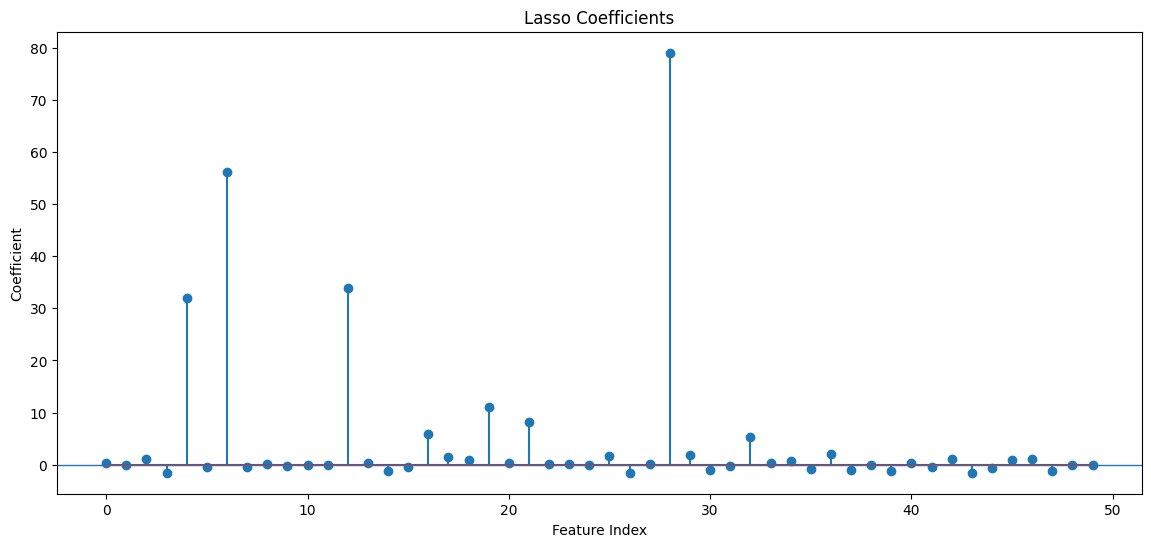

In [9]:
plt.figure(figsize=(14, 6))

plt.stem(
    range(len(lasso.coef_)),
    lasso.coef_
)

plt.axhline(0, linewidth=1)

plt.xlabel("Feature Index")
plt.ylabel("Coefficient")
plt.title("Lasso Coefficients")

plt.show()

# Effect of $\lambda$

The regularization parameter controls how strongly coefficients are penalized.

For small $\lambda$:

$$
\lambda \rightarrow 0
$$

Lasso behaves more like ordinary least squares.

For large $\lambda$:

$$
\lambda \rightarrow \infty
$$

the coefficients are strongly shrunk toward zero.

Conceptually:

$$
\text{Small } \lambda
\rightarrow
\text{Complex model}
$$

$$
\text{Large } \lambda
\rightarrow
\text{Sparse model}
$$

The challenge is choosing an appropriate value of $\lambda$.

## Regularization Path

In [10]:
alphas = np.logspace(-3, 1, 50)

coefficient_path = []

for alpha in alphas:
    model = Lasso(
        alpha=alpha,
        max_iter=10000
    )
    
    model.fit(X_train_scaled, y_train)
    
    coefficient_path.append(model.coef_)

coefficient_path = np.array(coefficient_path)

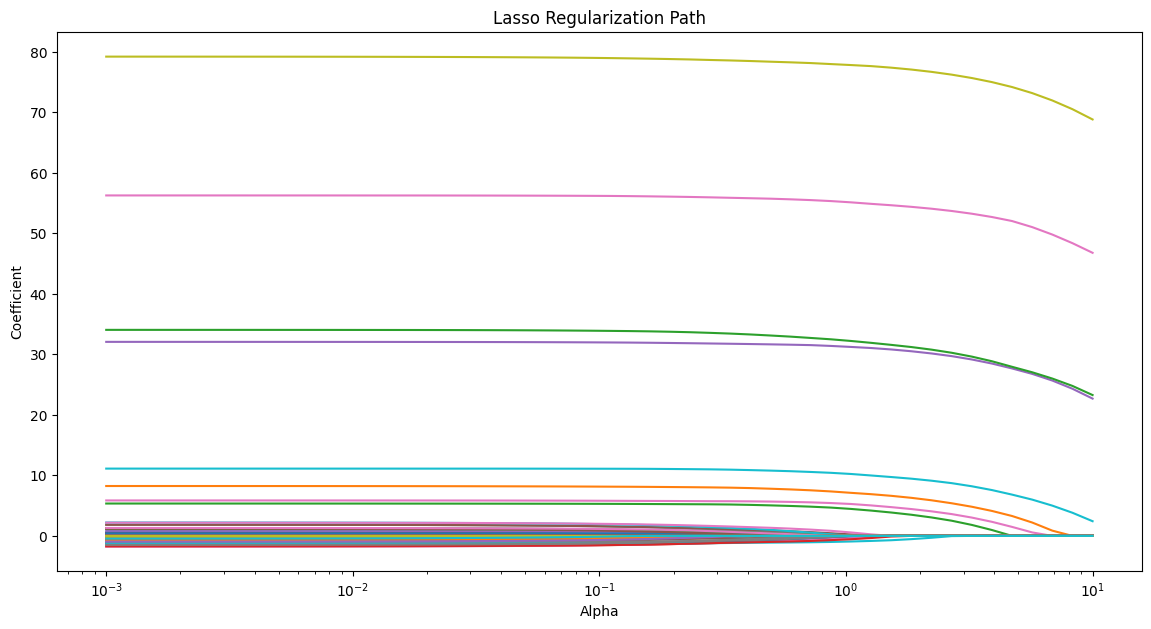

In [11]:
plt.figure(figsize=(14, 7))

for i in range(X.shape[1]):
    plt.plot(
        alphas,
        coefficient_path[:, i]
    )

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Coefficient")
plt.title("Lasso Regularization Path")

plt.show()

## Sparsity vs Regularization

In [12]:
nonzero_counts = []

for alpha in alphas:
    model = Lasso(
        alpha=alpha,
        max_iter=10000
    )
    
    model.fit(X_train_scaled, y_train)
    
    nonzero_counts.append(
        np.sum(model.coef_ != 0)
    )

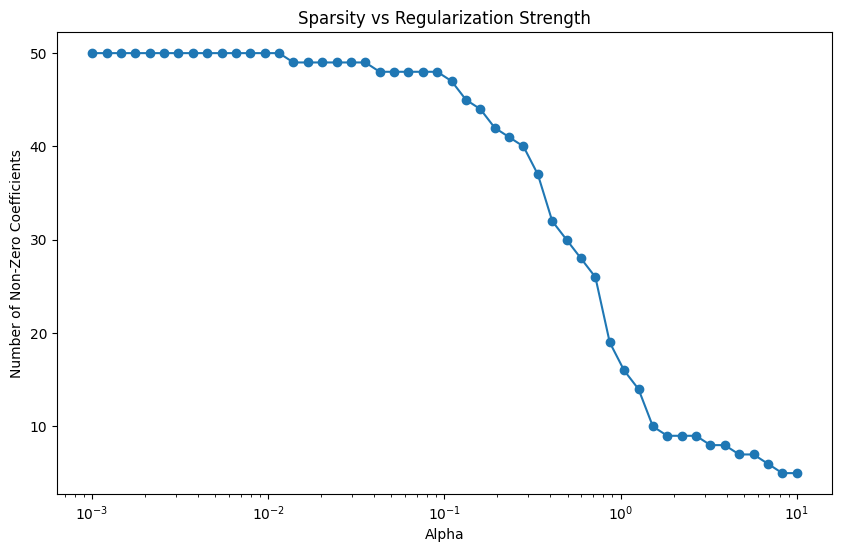

In [13]:
plt.figure(figsize=(10, 6))

plt.plot(
    alphas,
    nonzero_counts,
    marker="o"
)

plt.xscale("log")

plt.xlabel("Alpha")
plt.ylabel("Number of Non-Zero Coefficients")
plt.title("Sparsity vs Regularization Strength")

plt.show()

# Coordinate Descent

Lasso does not have a simple closed-form solution like ordinary least squares.

A common optimization approach is **coordinate descent**.

Instead of optimizing all coefficients simultaneously, coordinate descent repeatedly optimizes one coefficient at a time while keeping the others fixed.

Conceptually:

1. Initialize the coefficients.
2. Select one coefficient.
3. Optimize that coefficient.
4. Move to the next coefficient.
5. Repeat until convergence.

The L1 penalty leads to a soft-thresholding operation.

The soft-thresholding operator is:

$$
S(z,\lambda)
=
\operatorname{sign}(z)
\max(|z|-\lambda,0)
$$

This operation explains why Lasso can produce exact zeros.

If:

$$
|z| \leq \lambda
$$

then:

$$
S(z,\lambda)=0
$$

Therefore, the optimization procedure naturally sets some coefficients exactly to zero.

## Lasso and Feature Selection

In [14]:
feature_names = [
    f"Feature_{i}"
    for i in range(X.shape[1])
]

lasso_results = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lasso.coef_,
    "Selected": lasso.coef_ != 0
})

lasso_results.sort_values(
    "Coefficient",
    key=np.abs,
    ascending=False
).head(15)

,Feature,Coefficient,Selected
28,Feature_28,79.007063,True
6,Feature_6,56.206517,True
12,Feature_12,33.906998,True
4,Feature_4,31.986073,True
19,Feature_19,11.103855,True
21,Feature_21,8.146362,True
16,Feature_16,5.808662,True
32,Feature_32,5.299774,True
36,Feature_36,1.998302,True
29,Feature_29,1.946139,True


# Lasso vs Ridge

Both methods use regularization, but their penalties are different.

## Ridge

Ridge uses the L2 penalty:

$$
\hat{\beta}_{Ridge}
=
\arg\min_{\beta}
\left[
\frac{1}{2n}
\|y-X\beta\|_2^2
+
\lambda
\sum_{j=1}^{d}\beta_j^2
\right]
$$

Ridge shrinks coefficients toward zero but generally does not make them exactly zero.

## Lasso

Lasso uses the L1 penalty:

$$
\hat{\beta}_{Lasso}
=
\arg\min_{\beta}
\left[
\frac{1}{2n}
\|y-X\beta\|_2^2
+
\lambda
\sum_{j=1}^{d}|\beta_j|
\right]
$$

Lasso can make coefficients exactly zero.

Therefore:

| Method | Penalty | Exact zeros? | Feature selection |
|---|---|---:|---|
| OLS | None | Usually no | No |
| Ridge | L2 | Usually no | No |
| Lasso | L1 | Yes | Yes |

# Elastic Net

Lasso can have difficulties when predictors are highly correlated.

For example:

$$
X_1 \approx X_2 \approx X_3
$$

Lasso may arbitrarily select one feature and remove the others.

Elastic Net combines L1 and L2 regularization.

Its objective is:

$$
\hat{\beta}
=
\arg\min_{\beta}
\left[
\frac{1}{2n}
\|y-X\beta\|_2^2
+
\lambda
\left(
\alpha\|\beta\|_1
+
\frac{1-\alpha}{2}\|\beta\|_2^2
\right)
\right]
$$

where:

$$
0 \leq \alpha \leq 1
$$

When:

$$
\alpha=1
$$

Elastic Net becomes Lasso.

When:

$$
\alpha=0
$$

Elastic Net becomes Ridge-like regularization.

Therefore, Elastic Net combines:

- sparsity from L1 regularization
- stability from L2 regularization

## Elastic Net Implementation

In [15]:
from sklearn.linear_model import ElasticNet

elastic_net = ElasticNet(
    alpha=0.1,
    l1_ratio=0.5,
    max_iter=10000
)

elastic_net.fit(
    X_train_scaled,
    y_train
)

y_pred_enet = elastic_net.predict(X_test_scaled)

print("MSE:", mean_squared_error(y_test, y_pred_enet))
print("MAE:", mean_absolute_error(y_test, y_pred_enet))
print("R² :", r2_score(y_test, y_pred_enet))

print(
    "Non-zero coefficients:",
    np.sum(elastic_net.coef_ != 0)
)

MSE: 161.74803341276657
MAE: 9.559907830572296
R² : 0.9843350309682749
Non-zero coefficients: 46


## Lasso vs Elastic Net

### Lasso

Advantages:

- Produces sparse solutions
- Performs feature selection
- Easy to interpret
- Useful when only a small number of features are important

Disadvantages:

- Can be unstable with highly correlated features
- May select one feature from a correlated group
- Can discard useful correlated predictors

### Elastic Net

Advantages:

- Produces sparse solutions
- Handles correlated predictors better
- Combines L1 and L2 regularization
- Often more stable than Lasso

Disadvantages:

- Has more hyperparameters
- Requires tuning both overall regularization and the L1/L2 balance
- Less simple to interpret than pure Lasso

# Hyperparameter Selection

The regularization strength should not be chosen arbitrarily.

We can use cross-validation to find a suitable value.

For Lasso, we can use:

$$
\lambda^*
=
\arg\min_{\lambda}
CV(\lambda)
$$

where $CV(\lambda)$ represents the cross-validation error.

Scikit-learn provides `LassoCV` for this purpose.

In [16]:
from sklearn.linear_model import LassoCV

lasso_cv = LassoCV(
    alphas=None,
    cv=5,
    max_iter=10000,
    random_state=42
)

lasso_cv.fit(
    X_train_scaled,
    y_train
)

print("Best alpha:", lasso_cv.alpha_)

Best alpha: 0.7856883353551776


c:\Users\soumy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1682: FutureWarning: 'alphas=None' is deprecated and will be removed in 1.9, at which point the default value will be set to 100. Set 'alphas=100' to silence this warning.
  warnings.warn(


## Evaluate LassoCV

In [17]:
y_pred_cv = lasso_cv.predict(X_test_scaled)

print("MSE:", mean_squared_error(y_test, y_pred_cv))
print("MAE:", mean_absolute_error(y_test, y_pred_cv))
print("R² :", r2_score(y_test, y_pred_cv))

print(
    "Non-zero coefficients:",
    np.sum(lasso_cv.coef_ != 0)
)

MSE: 95.11960938420201
MAE: 8.257179817940036
R² : 0.9907878587215286
Non-zero coefficients: 23


## Cross-Validation Error

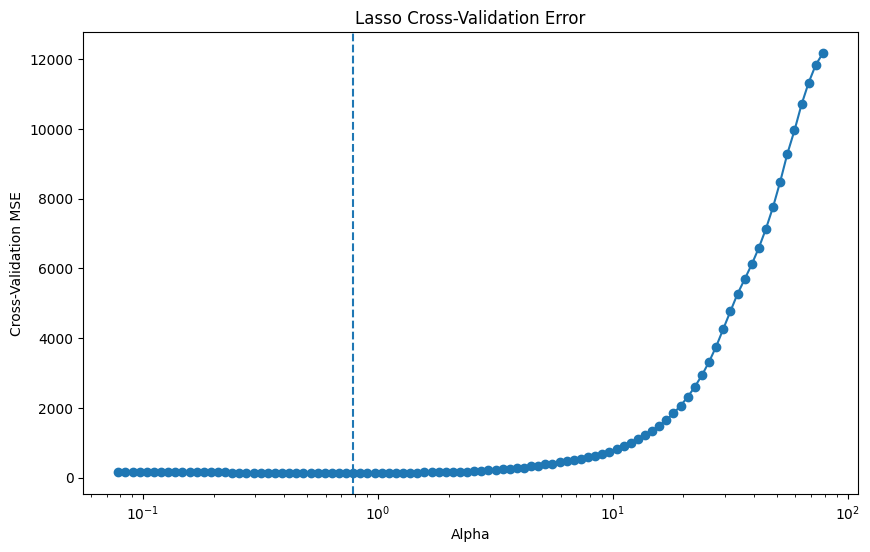

In [18]:
mse_path = lasso_cv.mse_path_.mean(axis=1)

plt.figure(figsize=(10, 6))

plt.plot(
    lasso_cv.alphas_,
    mse_path,
    marker="o"
)

plt.axvline(
    lasso_cv.alpha_,
    linestyle="--"
)

plt.xscale("log")

plt.xlabel("Alpha")
plt.ylabel("Cross-Validation MSE")
plt.title("Lasso Cross-Validation Error")

plt.show()

## Lasso vs OLS

In [19]:
comparison = pd.DataFrame({
    "Model": ["OLS", "Lasso", "LassoCV", "Elastic Net"],
    "MSE": [
        mean_squared_error(y_test, y_pred_ols),
        mean_squared_error(y_test, y_pred_lasso),
        mean_squared_error(y_test, y_pred_cv),
        mean_squared_error(y_test, y_pred_enet)
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred_ols),
        mean_absolute_error(y_test, y_pred_lasso),
        mean_absolute_error(y_test, y_pred_cv),
        mean_absolute_error(y_test, y_pred_enet)
    ],
    "R2": [
        r2_score(y_test, y_pred_ols),
        r2_score(y_test, y_pred_lasso),
        r2_score(y_test, y_pred_cv),
        r2_score(y_test, y_pred_enet)
    ]
})

comparison

,Model,MSE,MAE,R2
0,OLS,150.924402,9.645508,0.985383
1,Lasso,136.311312,9.122623,0.986799
2,LassoCV,95.119609,8.257180,0.990788
3,Elastic Net,161.748033,9.559908,0.984335


# Geometric Interpretation

The difference between L1 and L2 regularization can be understood geometrically.

Lasso constrains the coefficients using an L1 ball:

$$
\|\beta\|_1 \leq t
$$

In two dimensions, this constraint forms a diamond.

Ridge uses:

$$
\|\beta\|_2^2 \leq t
$$

which forms a circle.

The corners of the L1 constraint lie directly on the coordinate axes.

Because the optimization solution often touches these corners, one or more coefficients become exactly zero.

This geometric property explains the sparsity of Lasso.

Ridge has a smooth circular constraint, so exact zeros are much less likely.

# High-Dimensional Sparse Estimation

Sparse estimation becomes especially important when:

$$
d > n
$$

where:

- $d$ = number of features
- $n$ = number of observations

In this situation, the number of parameters exceeds the number of observations.

For example:

$$
n=100
$$

and:

$$
d=1000
$$

There are 1000 coefficients but only 100 observations.

OLS cannot uniquely estimate the coefficients without additional assumptions.

A sparse assumption provides useful structure:

$$
\|\beta\|_0 \ll d
$$

where:

$$
\|\beta\|_0
$$

represents the number of non-zero coefficients.

For example:

$$
\|\beta\|_0 = 10
$$

when:

$$
d=1000
$$

means that only 10 of the 1000 features are active.

Sparse estimation attempts to exploit this assumption.

# L0, L1 and L2 Regularization

Three important norms are:

### L0

$$
\|\beta\|_0
=
\text{number of non-zero coefficients}
$$

L0 directly measures sparsity.

However, optimization involving L0 is generally computationally difficult.

### L1

$$
\|\beta\|_1
=
\sum_j|\beta_j|
$$

L1 is convex and promotes sparsity.

This is why Lasso is widely used as a practical approximation to the ideal sparse optimization problem.

### L2

$$
\|\beta\|_2^2
=
\sum_j\beta_j^2
$$

L2 shrinks coefficients but usually does not produce exact zeros.

Therefore:

$$
L0
\rightarrow
\text{direct sparsity}
$$

$$
L1
\rightarrow
\text{practical sparse estimation}
$$

$$
L2
\rightarrow
\text{shrinkage and stability}
$$

# Advantages of Sparse Estimation

1. **Feature selection**

   Irrelevant features can receive zero coefficients.

2. **Interpretability**

   A model containing fewer active features is easier to understand.

3. **Reduced overfitting**

   Regularization controls model complexity.

4. **Useful for high-dimensional data**

   Sparse estimation is particularly useful when the number of features is large.

5. **Computational efficiency**

   A sparse model can require fewer active parameters.

6. **Automatic variable selection**

   Lasso performs estimation and feature selection simultaneously.

7. **Useful for scientific discovery**

   Sparse models can help identify potentially important variables in scientific datasets.

# Disadvantages of Sparse Estimation

1. **Choice of regularization strength**

   The value of $\lambda$ strongly affects the model.

2. **Potential underfitting**

   Excessive regularization can remove useful features.

3. **Correlated predictors**

   Lasso may behave unpredictably when predictors are highly correlated.

4. **Coefficient bias**

   Lasso shrinks coefficients toward zero, introducing bias.

5. **Scaling sensitivity**

   Features should generally be standardized before regularization.

6. **Interpretation is not always causal**

   A selected feature is predictive under the model, but this does not imply that it causes the target.

7. **Instability in feature selection**

   Small changes in the data can sometimes change which correlated features are selected.

# Important Considerations

Sparse estimation works particularly well when the underlying problem is approximately sparse.

The important assumption is:

$$
s \ll d
$$

where:

- $s$ = number of truly important features
- $d$ = total number of features

In other words, only a small fraction of the available variables are expected to be important.

However, sparse estimation is not automatically appropriate for every dataset.

If most features genuinely contribute to the target, forcing a sparse solution can hurt predictive performance.

# Practical Sparse Estimation Workflow

A practical workflow is:

### Step 1 — Prepare the dataset

Handle:

- missing values
- categorical variables
- outliers
- data leakage

### Step 2 — Split the data

Create training and testing sets.

### Step 3 — Scale numerical features

Standardization is usually important for regularized linear models.

### Step 4 — Fit a baseline model

Start with OLS or another simple baseline.

### Step 5 — Fit a sparse model

Try Lasso or Elastic Net.

### Step 6 — Tune regularization

Use cross-validation to select $\lambda$.

### Step 7 — Examine sparsity

Check:

$$
\#\{\beta_j \neq 0\}
$$

### Step 8 — Evaluate predictive performance

Use appropriate validation metrics.

### Step 9 — Inspect selected features

Understand which variables remain active.

### Step 10 — Validate stability

Check whether selected features remain consistent across different samples or folds.